# Feature Extraction

Data representation plays a critical role in the performance of many machine learning methods in machine learning. The data representation of network traffic often determines the effectiveness of these models as much as the model itself. The wide range of novel events that network operators need to detect (e.g., attacks, malware, new applications, changes in traffic demands) introduces the possibility for a broad range of possible models and data representations.

[NetML](https://pypi.org/project/netml/) is an open-source tool and end-to-end pipeline for anomaly detection in network traffic. This notebook walks through the use of that library.

First, let us load the library.

In [1]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Specify a Packet Capture File

Create a pcap data structure for which we would like to extract features. You could do this based on the packet capture files that we have been using in previous hands assignments. Any packet capture file will suffice, however.

You can define the minumum number of packets that you want to include in each flow.

In [2]:
pcap = PCAP("data/port80.pcap", flow_ptks_thres=2)

## Convert the Packet Capture Into Flows

Find the function in `netml` that converts the pcap file into flows. Examing the resulting data structure. What does it contain?

In [3]:
pcap.pcap2flows()
print(f"Number of flows: {len(pcap.flows)}")
print(f"Computed split interval: {pcap.interval:.4f} seconds")

Number of flows: 148
Computed split interval: 1.2471 seconds


## Explore the Flows

How many flows are in your data structure?

In [4]:
print(f"Total flows: {len(pcap.flows)}")

Total flows: 148


What other information does the flow data structure contain, for each flow?

In [5]:
fid, pkts = pcap.flows[0]

print(f"Flow key: {fid}")
print(f"  src_ip:   {fid[0]}")
print(f"  dst_ip:   {fid[1]}")
print(f"  src_port: {fid[2]}")
print(f"  dst_port: {fid[3]}")
print(f"  protocol: {fid[4]} (TCP)")
print(f"\nNumber of packets in this flow: {len(pkts)}")
print(f"First packet: {pkts[0].summary()}")

Flow key: ('243.186.23.169', '238.4.62.5', 60465, 80, 6)
  src_ip:   243.186.23.169
  dst_ip:   238.4.62.5
  src_port: 60465
  dst_port: 80
  protocol: 6 (TCP)

Number of packets in this flow: 4
First packet: Ether / IP / TCP 243.186.23.169:60465 > 238.4.62.5:http PA / Raw


## Extract Features from Each Flow

Use the `netml` library to extract features from each flow. 

The [documentation](https://pypi.org/project/netml/) and [accompanying paper](https://arxiv.org/pdf/2006.16993.pdf) provide examples of features that you can try to extract. 

First try to extract the inter-arrival times for each flow.

### Interarrival Times

In [6]:
pcap.flow2features("IAT", fft=False, header=False)
print(f"Feature matrix shape: {pcap.features.shape}")
print(f"(rows = flows, columns = IAT values per flow)")
print(f"\nFirst flow's IAT features:\n{pcap.features[0]}")

Feature matrix shape: (148, 30)
(rows = flows, columns = IAT values per flow)

First flow's IAT features:
[0.01328111 1.10609984 0.01267815 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]


### Explore the Per-Flow Features

Inspect and print the features for each flow. (If you feel compelled: Get fancy! Plot distributions, etc. Whatever you like!)

Non-zero IAT values: 1167
Mean IAT: 0.0486 seconds
Median IAT: 0.0001 seconds
Max IAT: 1.2442 seconds


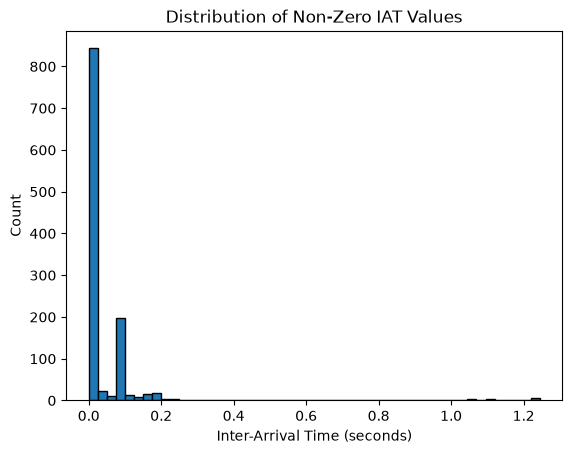

In [7]:
import matplotlib.pyplot as plt
import numpy as np

non_zero = pcap.features[pcap.features > 0]
print(f"Non-zero IAT values: {len(non_zero)}")
print(f"Mean IAT: {np.mean(non_zero):.4f} seconds")
print(f"Median IAT: {np.median(non_zero):.4f} seconds")
print(f"Max IAT: {np.max(non_zero):.4f} seconds")

plt.hist(non_zero, bins=50, edgecolor='black')
plt.xlabel("Inter-Arrival Time (seconds)")
plt.ylabel("Count")
plt.title("Distribution of Non-Zero IAT Values")
plt.show()

### Other Features and Options

1. Try some of the other features in the `netml` library.

  Here are some of the other possibilities, which can be passed to the library:
  * IAT: A flow is represented as a timeseries of inter-arrival times between packets, i.e., elapsed time in seconds between any two packets in the flow.   
  *  STATS: A flow is represented as a set of statistical quantities. We choose ten of the most common such
statistics in the literature: flow duration, number of packets sent per second, number of bytes
per second, and various statistics on packet sizes within each flow: mean, standard deviation, inter-quartile range,
minimum, and maximum.
  * SIZE: A flow is represented as a timeseries of packet sizes in bytes, with one sample per packet. 
  * SAMP-NUM: A flow is partitioned into small intervals of equal length 𝛿𝑡, and the number of packets in each interval is recorded; thus, a flow is represented as a timeseries of packet counts in small time intervals, with one sample per time interval. Here, 𝛿𝑡 might be viewed as a choice of sampling rate for the timeseries, hence the nomenclature.
  * SAMP-SIZE: A flow is partitioned into time intervals of equal length 𝛿𝑡, and the total packet size (i.e., byte count) in each interval is recorded; thus, a flow is represented as a timeseries of byte counts in small time intervals, with one sample per time interval.
  

  
2. One of the challenges with providing packet traces to models involve ensuring that all feature vectors are of the same length. The `netml` libary will do that for you, but there are a number of different ways to solve the problem. What do some of the following options do?  Explore how different settings of the following affect the dimensionality of your resulting feature vector.

 * flow_ptks_thres
 * q_interval

## Thought Questions

What other features might you want to extract from packet captures that are not provided by the `netml` library?